<a href="https://colab.research.google.com/github/DenysovOleksii/Data-Driven-Retail-Analysis-SQL-Python-Tableau/blob/main/Ecommerce_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import auth
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
auth.authenticate_user()


In [2]:
#Connecting to DB and making dataset throught SQL query
project_id='data-analytics-mate'
query="""
SELECT
s.date,
o.ga_session_id,
sp.* EXCEPT(ga_session_id,medium,name),
sp.name as traffic_info,
acs.account_id,
acc.is_unsubscribed,
acc.is_verified,
p.* EXCEPT(item_id,name),
p.name as product_name
FROM `data-analytics-mate.DA.order` o
LEFT JOIN `data-analytics-mate.DA.product` p
ON o.item_id=p.item_id
LEFT JOIN `data-analytics-mate.DA.session` s
ON o.ga_session_id=s.ga_session_id
LEFT JOIN `data-analytics-mate.DA.session_params` sp
ON o.ga_session_id=sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` acs
ON o.ga_session_id=acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` acc
ON acs.account_id=acc.id
"""
df=pd.read_gbq(query,project_id=project_id)
df.info()

/tmp/ipykernel_8119/1367904612.py:26: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df=pd.read_gbq(query,project_id=project_id)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33538 entries, 0 to 33537
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               33538 non-null  dbdate 
 1   ga_session_id      33538 non-null  Int64  
 2   device             33538 non-null  object 
 3   mobile_model_name  33538 non-null  object 
 4   operating_system   33538 non-null  object 
 5   language           22531 non-null  object 
 6   browser            33538 non-null  object 
 7   continent          33538 non-null  object 
 8   country            33538 non-null  object 
 9   channel            33538 non-null  object 
 10  traffic_info       33538 non-null  object 
 11  account_id         2781 non-null   Int64  
 12  is_unsubscribed    2781 non-null   Int64  
 13  is_verified        2781 non-null   Int64  
 14  category           33538 non-null  object 
 15  price              33538 non-null  float64
 16  short_description  335

## Опис датасету (Exploratory Data Analysis)

На основі вивантажених даних із Google BigQuery за період з **01.11.2020** по **27.01.2021**, було проведено первинний аналіз структури датасету.

### 1. Загальні характеристики
* **Загальна кількість рядків:** 33 538
* **Загальна кількість колонок:** 18
* **Кількість унікальних сесій:** 33 538 (кожен рядок відповідає унікальній сесії)


### 2. Типи даних
| Тип | Кількість | Колонки |
| :--- | :--- | :--- |
| **Числові (Numeric)** | 6 | `ga_session_id`, `account_id`, `is_unsubscribed`, `is_verified`, `price` |
| **Категоріальні (Object)** | 11 | `device`, `mobile_model_name`, `operating_system`, `language`, `browser`, `continent`, `country`, `channel`, `traffic_info`, `category`, `short_description`, `product_name` |
| **Дата (Datetime)** | 1 | `date` |

### 3. Аналіз пропущених значень (Missing Values)

У датасеті спостерігається значна кількість пропущених значень у певних колонках, що зумовлено специфікою збору даних.

| Колонка | Кількість пропусків | Причина виникнення |
| :--- | :--- | :--- |
| `account_id` | 30 757 | Більшість користувачів здійснюють покупки або перегляди без реєстрації (гостьові сесії). |
| `is_unsubscribed`| 30 757 | Дані доступні лише для профілів зареєстрованих користувачів. |
| `is_verified` | 30 757 | Статус підтвердження email існує лише для створених акаунтів. |
| `language` | 11 007 | Технічні обмеження браузерів або налаштування приватності користувачів, які не передають мовні параметри. |

**Висновок:** Датасет репрезентує переважно неавторизований трафік, що є типовим для інтернет-магазинів.

#Частина 1: Базові метрики, Географія та Користувачі

##Географічний лідерборд

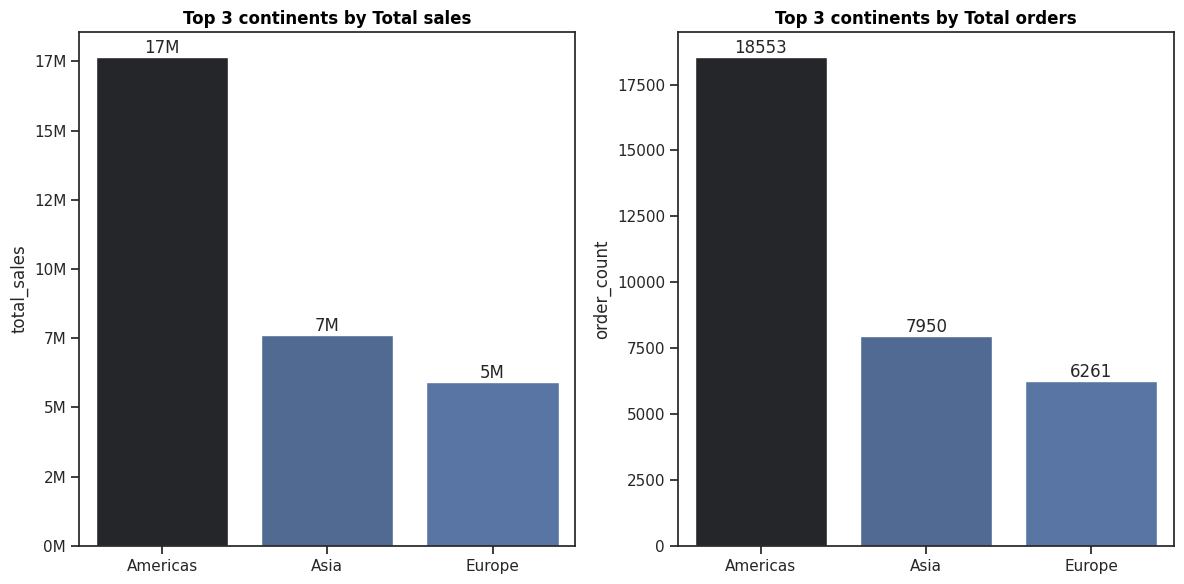

In [53]:
#Топ 3 континенти по продажам та кількістю замовлень

df_top3_cont=df.groupby("continent").agg(
    total_sales=("price", "sum"),
    order_count=("ga_session_id", "count")
).sort_values(by="total_sales", ascending=False).reset_index().head(3)
sns.set_theme(style="ticks")
fig,ax=plt.subplots(1,2,figsize=(12,6))
plot=sns.barplot(data=df_top3_cont,x="continent",y="total_sales", hue="total_sales",palette="dark:b_r",ax=ax[0],legend=False)
ax[0].set_title("Top 3 continents by Total sales",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{int(x/1000000)}M"))
ax[0].set_xlabel("")
for bar in plot.containers:
  plot.bar_label(bar,fmt=plt.FuncFormatter(lambda x,_:f"{int(x/1000000)}M"))
plot2=sns.barplot(data=df_top3_cont,x="continent",y="order_count", hue="order_count",palette="dark:b_r",ax=ax[1],legend=False)
ax[1].set_title("Top 3 continents by Total orders",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[1].set_xlabel("")
for bar in plot2.containers:
  plot2.bar_label(bar)
plt.tight_layout()
plt.show()


### 🌍 Географічний аналіз продажів: Континенти-лідери

Аналіз розподілу загального обсягу продажів (Загальні продажі) та кількості замовлень (Загальна кількість замовлень) у розрізі континентів виявив абсолютного лідера ринку — **макрорегіон Америка**.

| Континент | Обсяг продажів ($) | Кількість замовлень | Частка у продажах (%) |
| :--- | :---: | :---: | :---: |
| **Америка** | 17M | 18 553 | ~58.6% |
| **Азія** | 7M | 7 950 | ~24.1% |
| **Європа** | 5M | 6 261 | ~17.3% |

#### 🔑 Ключові інсайти:
* **Домінування американського ринку:** Регіон **Америка** генерує понад **58% усіх прибутків** компанії (17 млн) та забезпечує левову частку транзакцій (18 553 замовлення). Це ключовий та найбільш зрілий ринок для нашого інтернет-магазину.
* **Співвідношення Азії та Європи:** **Азія** впевнено посідає друге місце з обсягом у 7 млн продажів та 7 950 замовлень. **Європа** замикає топ-3 (5 млн продажів та 6 261 замовлення).
* **Стабільність середнього чека:** Розподіл замовлень майже ідеально пропорційний обсягам продажів на всіх трьох континентах. Це свідчить про те, що середній чек (AOV) у різних регіонах є приблизно однаковим, і масштабування виторгу відбувається саме за рахунок залучення більшої кількості сесій та транзакцій, а не через продаж дорожчих товарів у конкретних регіонах.

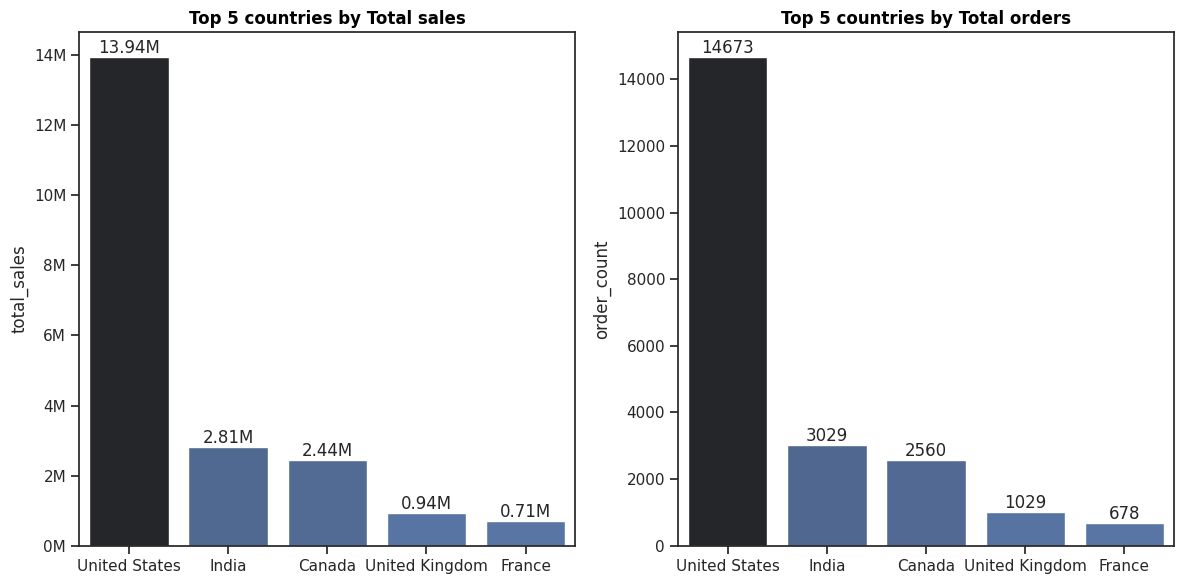

In [85]:
#Топ 5 крайїн по продажам та кількістю замовлень

df_top5_count=df.groupby("country").agg(
    total_sales=("price", "sum"),
    order_count=("ga_session_id", "count")
).sort_values(by="total_sales", ascending=False).reset_index().head(5)
sns.set_theme(style="ticks")
fig,ax=plt.subplots(1,2,figsize=(12,6))
plot=sns.barplot(data=df_top5_count,x="country",y="total_sales", hue="total_sales",palette="dark:b_r",ax=ax[0],legend=False)
ax[0].set_title("Top 5 countries by Total sales",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{int(x/1000000)}M"))
ax[0].set_xlabel("")
for bar in plot.containers:
  plot.bar_label(bar,fmt=plt.FuncFormatter(lambda x,_:f"{x/1000000:.2f}M"))
plot2=sns.barplot(data=df_top5_count,x="country",y="order_count", hue="order_count",palette="dark:b_r",ax=ax[1],legend=False)
ax[1].set_title("Top 5 countries by Total orders",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[1].set_xlabel("")
for bar in plot2.containers:
  plot2.bar_label(bar)
plt.tight_layout()
plt.show()

### 🏳️ Географічний аналіз продажів: Країни-лідери

Глибокий аналіз у розрізі конкретних країн підтверджує критичну залежність бізнесу від одного ключового географічного ринку, а також формує чіткий пул регіонів для подальшого масштабування.

| Країна | Обсяг продажів, USD | Кількість замовлень | Середній чек (AOV, USD) |
|:---|:---|:---|:---|
| США | 13.94M | 14 673 | ~950 |
| Індія | 2.81M | 3 029 | ~927 |
| Канада | 2.44M | 2 560 | ~952 |
| Велика Британія | 0.94M | 1 029 | ~911 |
| Франція | 0.71M | 678 | ~1 047 |

#### 🔑 Ключові інсайти:

* **Абсолютне домінування США:** Сполучені Штати є головним джерелом прибутку, генеруючи **13.94 млн USD** продажів та забезпечуючи **14 673 замовлення**. Це становить близько **41.5%** від усього виторгу компанії.
* **Потенціал азійського вектору (Індія):** **Індія** впевнено посідає друге місце (**2.81 млн USD** та **3 029 замовлень**). Це ключовий ринок у регіоні Азія, який демонструє високу щільність транзакцій.
* **Ефективність європейського ринку (Франція):** Попри те, що **Франція** замикає Топ-5 за загальними обсягами (0.71 млн USD всього 678 замовлень), вона має найвищий середній чек серед лідерів — **понад 1000 USD** на замовлення.

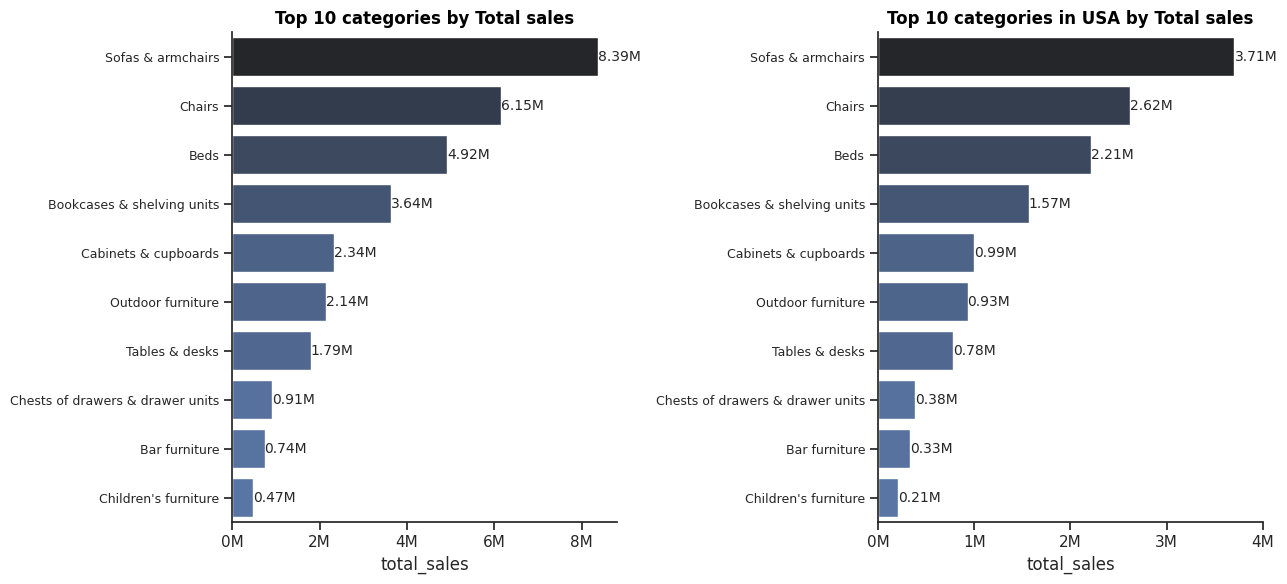

In [105]:
#Топ 10 категорій загально та у США
df_top10_category=df.groupby("category")["price"].sum().sort_values(ascending=False).reset_index(name="total_sales").head(10)
sns.set_theme(style="ticks")
fig,ax=plt.subplots(1,2,figsize=(13,6))
plot=sns.barplot(data=df_top10_category,y="category",x="total_sales", hue="total_sales",palette="dark:b_r",ax=ax[0],legend=False)
ax[0].set_title("Top 10 categories by Total sales",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{int(x/1000000)}M"))
ax[0].set_ylabel("")
ax[0].tick_params(axis='y', labelsize=9)
for bar in plot.containers:
  plot.bar_label(bar,fmt=plt.FuncFormatter(lambda x,_:f"{x/1000000:.2f}M"),fontsize=10)
df_top10usa_category=df[df["country"]=="United States"].groupby("category")["price"].sum().sort_values(ascending=False).reset_index(name="total_sales").head(10)
plot2=sns.barplot(data=df_top10usa_category,y="category",x="total_sales", hue="total_sales",palette="dark:b_r",ax=ax[1],legend=False)
ax[1].set_title("Top 10 categories in USA by Total sales",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{int(x/1000000)}M"))
ax[1].set_ylabel("")
ax[1].tick_params(axis='y', labelsize=9)
ax[1].set_xticks([0, 1000000, 2000000, 3000000, 4000000])
for bar in plot2.containers:
  plot2.bar_label(bar,fmt=plt.FuncFormatter(lambda x,_:f"{x/1000000:.2f}M"),fontsize=10)
sns.despine()
plt.tight_layout()



### 📦 Категоріальний аналіз: Топ-10 категорій товарів

Аналіз структури продажів у розрізі категорій товарів дозволяє оцінити продуктові драйвери компанії, а також зіставити глобальні тренди споживчого попиту з уподобаннями клієнтів на ключовому ринку — в США.

| № | Категорія товару | Загальний виторг (USD) | Виторг в США (USD) | Частка ринку США (%) |
|:---|:---|:---|:---|:---|
| 1 | Sofas & armchairs | 8.39 M | 3.71 M | ~44.2% |
| 2 | Chairs | 6.15 M | 2.62 M | ~42.6% |
| 3 | Beds | 4.92 M | 2.21 M | ~44.9% |
| 4 | Bookcases & shelving units | 3.64 M | 1.57 M | ~43.1% |
| 5 | Cabinets & cupboards | 2.34 M | 0.99 M | ~42.3% |
| 6 | Outdoor furniture | 2.14 M | 0.93 M | ~43.5% |
| 7 | Tables & desks | 1.79 M | 0.78 M | ~43.6% |
| 8 | Chests of drawers & drawer units | 0.91 M | 0.38 M | ~41.8% |
| 9 | Bar furniture | 0.74 M | 0.33 M | ~44.6% |
| 10 | Children's furniture | 0.47 M | 0.21 M | ~44.7% |

#### 🔑 Ключові інсайти:

* **Повна ідентичність споживчої поведінки:** Структура попиту на топ-10 категорій товарів на глобальному рівні та всередині США є **абсолютно дзеркальною**. Позиції всіх товарних груп у рейтингу збігаються один в один — від абсолютного лідера `Sofas & armchairs` до замикаючої позиції `Children's furniture`. Це підтверджує універсальність продуктового портфеля компанії та єдині паттерни вибору меблів незалежно від регіону.
* **Ядро асортименту (Топ-3):** Головними драйверами доходу бізнесу виступають три категорії: **Sofas & armchairs** (8.39M загалом), **Chairs** (6.15M) та **Beds** (4.92M). Ця трійка формує основний фінансовий потік компанії.
* **Стабільна частка американського вектора:** На кожній продуктовій позиції чітко простежується, що ринок США стабільно акумулює **від 42% до 45%** загального світового виторгу конкретної категорії. Це ще раз підкреслює критичну залежність загального результату компанії від успіху американського підрозділу.

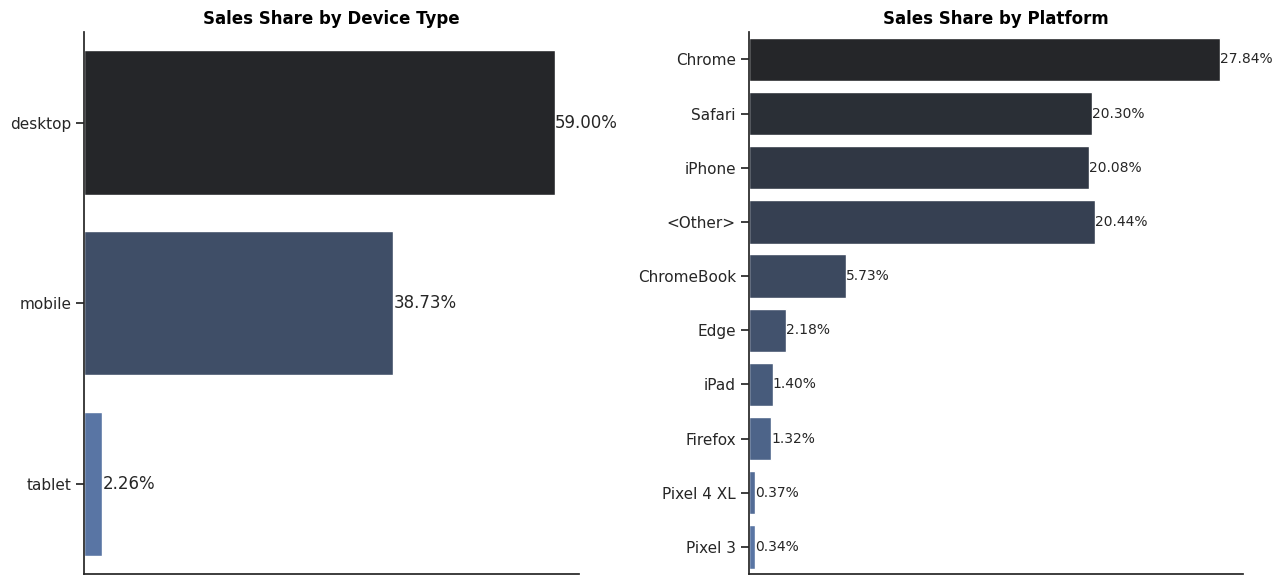

In [184]:
df_devices=df.groupby(["device","mobile_model_name"])["price"].sum().reset_index(name="total_sales").sort_values(by="total_sales",ascending=False)
df_devices["percent"]=df_devices['total_sales']/df['price'].sum()*100
fig,ax=plt.subplots(1,2,figsize=(13,6))
sns.set_theme(style="ticks")
plot=sns.barplot(data=df_devices,y="device",x="percent",ax=ax[0],errorbar=('ci', False),estimator="sum",palette="dark:b",hue="device")
ax[0].set_title("Sales Share by Device Type",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{x}%"))
ax[0].set_ylabel("")
ax[0].set_xlabel("")
for bar in plot.containers:
  plot.bar_label(bar,fmt=plt.FuncFormatter(lambda x,_:f"{x:.2f}%"))
plot2=sns.barplot(data=df_devices,y="mobile_model_name",x="percent",ax=ax[1],errorbar=('ci', False),estimator="sum",palette="dark:b",hue="mobile_model_name")
ax[1].set_title("Sales Share by Platform",fontsize=12,fontweight="bold",color="Black",ha="center")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{x}%"))
ax[1].set_ylabel("")
ax[1].set_xlabel("")
for bar in plot2.containers:
   plot2.bar_label(bar,fmt=plt.FuncFormatter(lambda x,_:f"{x:.2f}%"),fontsize=10)
ax[0].get_xaxis().set_visible(False)
ax[1].get_xaxis().set_visible(False)
sns.despine()
plt.tight_layout()


### 💻 Технічний аналіз: Продажі у розрізі девайсів та платформ

Цей етап аналізу дозволяє визначити технічні характеристики сесій, які приносять компанії найбільший дохід. Через специфіку збору даних (Google Analytics), загальний тип пристрою (`device`) деталізується через назву платформи або моделі (`model_name`), де для десктопів фіксується веб-браузер, а для мобільних — конкретний девайс.

#### 📊 Глобальний розподіл та Топ-10 платформ за часткою продажів

| № | Тип пристрою (device) | Частка (%) | | № | Платформа / Модель (model_name) | Частка (%) |
|:---|:---|:---|:---|:---|:---|:---|
| 1 | **desktop** | 59.00% | | 1 | Chrome | 27.84% |
| 2 | **mobile** | 38.73% | | 2 | <Other> | 20.44% |
| 3 | **tablet** | 2.26% | | 3 | Safari | 20.30% |
|   |            |        | | 4 | iPhone | 20.08% |
|   |            |        | | 5 | ChromeBook | 5.73% |
|   |            |        | | 6 | Edge | 2.18% |
|   |            |        | | 7 | iPad | 1.40% |
|   |            |        | | 8 | Firefox | 1.32% |
|   |            |        | | 9 | Pixel 4 XL | 0.37% |
|   |            |        | | 10 | Pixel 3 | 0.34% |

#### 🔑 Ключові інсайти:

* **Домінування десктопного сегменту:** Понад **59% всього виторгу** компанії генерують користувачі настільних комп'ютерів (`desktop`). Основними інструментами є браузери `Chrome` (27.84%) та `Safari` (20.30%). Це підтверджує, що класична web-версія сайту є головним та найбільш конверсійним каналом монетизації.
* **Смартфони як потужний другий канал:** Мобільні пристрої (`mobile`) міцно утримують частку в **38.73%**. При цьому всередині мобільного сегменту спостерігається чіткий поділ: користувачі **iPhone** забезпечують аж **20.08%** від загальних світових продажів компанії, повністю домінуючи над смартфонами на Android (лінійки Pixel 3/4 сукупно приносять менше 1%).

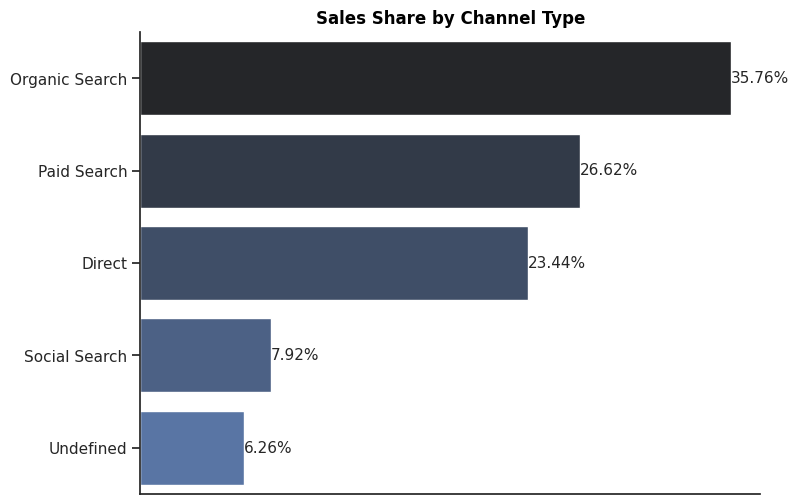

In [195]:
df_channels=df.groupby("channel")["price"].sum().reset_index(name="total_sales").sort_values(by="total_sales",ascending=False)
df_channels["percent"]=df_channels['total_sales']/df['price'].sum()*100
plt.figure(figsize=(8, 6))
sns.set_theme(style="ticks")
plot=sns.barplot(data=df_channels,y="channel",x="percent",errorbar=('ci', False),estimator="sum",palette="dark:b",hue="channel")
plot.set_title("Sales Share by Channel Type",fontsize=12,fontweight="bold",color="Black",ha="center")
plot.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{x}%"))
plot.set_ylabel("")
plot.set_xlabel("")
plot.get_xaxis().set_visible(False)
sns.despine()
for bar in plot.containers:
  plot.bar_label(bar,fmt=plt.FuncFormatter(lambda x,_:f"{x:.2f}%"),fontsize=11)

### 🌐 Аналіз каналів трафіку: Розподіл продажів

Цей етап аналізу дозволяє оцінити ефективність маркетингових каналів залучення користувачів та зрозуміти, які джерела генерують основний обсяг фінансового результату компанії.

#### 📊 Структура продажів за джерелами трафіку (Channel Type)

| № | Канал трафіку (Channel Type) | Частка від загальних продажів (%) | Роль у маркетинговій стратегії |
|:---|:---|:---|:---|
| 1 | **Organic Search** | 35.76% | Основний драйвер умовно-безкоштовного трафіку (SEO) |
| 2 | **Paid Search** | 26.62% | Головний платний канал залучення (Контекстна реклама) |
| 3 | **Direct** | 23.44% | Прямі заходи (Ядро лояльної аудиторії / Сила бренду) |
| 4 | **Social Search** | 7.92% | Допоміжний канал залучення через соціальні мережі |
| 5 | **Undefined** | 6.26% | Технічні сесії без визначеного UTM-джерела |

#### 🔑 Ключові інсайти:

* **Домінування пошукового вектору (Понад 62%):** Сумарно органічний та платний пошук (`Organic Search` + `Paid Search`) забезпечують понад **62% всього виторгу** компанії. Це свідчить про те, що продукт має сформований попит, і користувачі активно шукають його через пошукові системи.
* **Здоровий баланс між платоспроможністю та витратами:** Найбільшу частку доходу приносить безкоштовний органічний пошук (**35.76%**), що вказує на сильну SEO-оптимізацію та високу позицію сайту в пошуковиках. При цьому платна реклама (`Paid Search` — **26.62%**) виступає потужним паливом, що підтримує високу швидкість масштабування продажів.
* **Високий рівень лояльності бренду:** Прямі заходи на сайт (`Direct`) генерують майже чверть доходу (**23.44%**). Це чудовий показник для e-commerce, який підтверджує, що значна частина клієнтів повертається до магазину напряму (через закладки або пам'ять), довіряє бренду та має високий рівень утримання (Retention).